# debug

In [1]:
from zs_fhn.models.ode import simulate_ode
from zs_fhn.visualize.plots import plot_phase_plane_with_trajectory, interactive_phase_plane



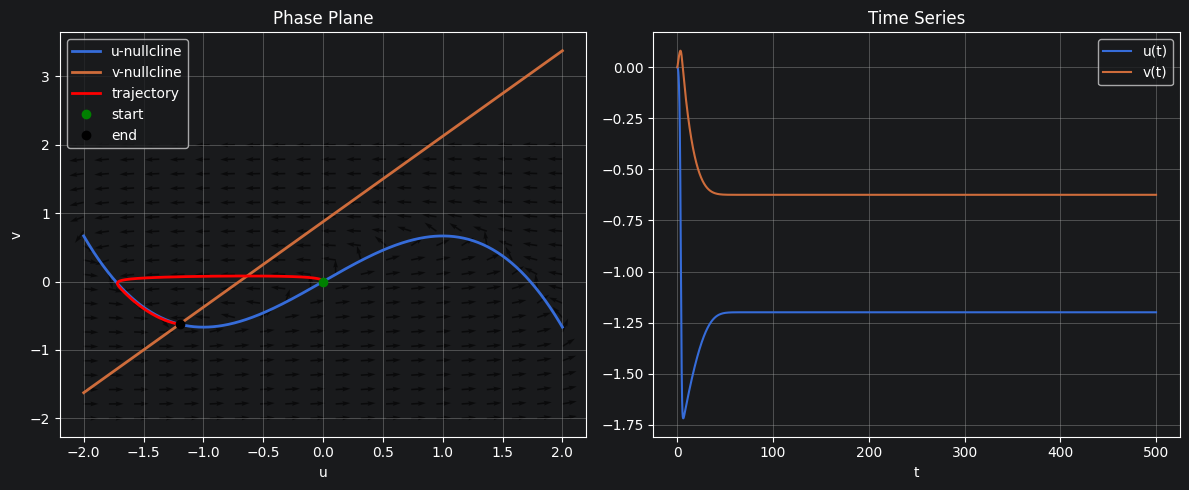

In [2]:
params = {
    "epsilon": 0.05,
    "a": 0.7,
    "b": 0.8,
    "dt": 0.01,
    "T": 500
}

plot_phase_plane_with_trajectory(0.0, 0.0, params)

In [3]:
interactive_phase_plane(params)

interactive(children=(FloatSlider(value=0.0, description='u0', max=2.0, min=-2.0), FloatSlider(value=0.0, desc…

In [4]:
import numpy as np

from zs_fhn.config import default_params, scan3d_default_grid
from zs_fhn.experiments.parameter_scan import parameter_scan_3d

# ===== 初始化参数 =====
params = default_params()

# 🔥 强制关键数值（你要求的）
params["T"] = 200
params["dt"] = 0.01

# 可选：固定一个典型点
params["epsilon"] = 0.05
params["a"] = 0.7
params["b"] = 0.8

print("当前参数：")
print(params)

当前参数：
{'epsilon': 0.05, 'a': 0.7, 'b': 0.8, 'dt': 0.01, 'T': 200, 'L': 100.0, 'Nx': 200, 'Du': 0.1, 'Dv': 0.05}


In [7]:
results = parameter_scan_3d(
    a_vals=np.linspace(0.1, 1.2, 50),
    b_vals=np.linspace(0.1, 1.0, 50),
    eps_vals=np.linspace(0.03, 0.1, 50),
    base_params=params,
    fast_mode=False,   # 🔥 这里已经用 T=200，不用 fast_mode
    n_jobs=24           # 避免 notebook 卡死
)

print("结果数量:", len(results))
print("前几个结果:", results[:5])

100%|██████████| 125000/125000 [00:22<00:00, 5550.15it/s]

结果数量: 125000
前几个结果: [(np.float64(0.1), np.float64(0.1), np.float64(0.03), True), (np.float64(0.1), np.float64(0.1), np.float64(0.0642857142857143), True), (np.float64(0.1), np.float64(0.1), np.float64(0.06571428571428573), True), (np.float64(0.1), np.float64(0.1), np.float64(0.06714285714285714), True), (np.float64(0.1), np.float64(0.1), np.float64(0.06857142857142857), True)]


In [8]:
import pandas as pd
import numpy as np
import plotly.express as px


def plot_results_3d(
    results,
    max_points=100000,
    mode="balanced",   # "balanced", "osc_only", "stable_only"
    marker_size=2,
    opacity=0.6
):
    """
    Plot 3D parameter scan results (from precomputed results).

    Parameters
    ----------
    results : list of tuples
        (a, b, epsilon, is_osc)
    max_points : int
        Max number of points to plot
    mode : str
        "balanced" / "osc_only" / "stable_only"
    """

    print("Converting to DataFrame...")
    df = pd.DataFrame(results, columns=["a", "b", "epsilon", "osc"])

    print(f"Total points: {len(df)}")

    # =========================
    # 模式过滤
    # =========================
    if mode == "osc_only":
        df = df[df["osc"] == True]
    elif mode == "stable_only":
        df = df[df["osc"] == False]

    print(f"After filtering: {len(df)}")

    # =========================
    # 🔥 下采样（关键）
    # =========================
    if len(df) > max_points:
        print(f"Downsampling to {max_points} points...")

        if mode == "balanced":
            df_true = df[df["osc"] == True]
            df_false = df[df["osc"] == False]

            n_true = int(max_points * len(df_true) / len(df))
            n_false = max_points - n_true

            df = pd.concat([
                df_true.sample(min(n_true, len(df_true)), random_state=42),
                df_false.sample(min(n_false, len(df_false)), random_state=42)
            ])
        else:
            df = df.sample(max_points, random_state=42)

    print(f"Plotting {len(df)} points...")

    # =========================
    # 标签优化
    # =========================
    df["label"] = df["osc"].map({
        True: "Oscillating",
        False: "Stable"
    })

    # =========================
    # Plot
    # =========================
    fig = px.scatter_3d(
        df,
        x="a",
        y="b",
        z="epsilon",
        color="label",
        opacity=opacity,
        title="3D Parameter Scan"
    )

    fig.update_traces(marker=dict(size=marker_size))

    fig.show()

In [9]:
plot_results_3d(results, max_points=50000)

Converting to DataFrame...
Total points: 125000
After filtering: 125000
Downsampling to 50000 points...
Plotting 50000 points...


In [10]:
plot_results_3d(results, mode="stable_only")

Converting to DataFrame...
Total points: 125000
After filtering: 61910
Plotting 61910 points...


In [5]:
from zs_fhn.config import default_params
from zs_fhn.visualize.plots import interactive_3d_scan

In [6]:
params = default_params()

# 🔥 你现在的标准
params["T"] = 200
params["dt"] = 0.01

# 给一个典型参数点（避免极端情况）
params["epsilon"] = 0.05
params["a"] = 0.7
params["b"] = 0.8

print(params)

{'epsilon': 0.05, 'a': 0.7, 'b': 0.8, 'dt': 0.01, 'T': 200, 'L': 100.0, 'Nx': 200, 'Du': 0.1, 'Dv': 0.05}


In [7]:
interactive_3d_scan(params)

In [14]:
import plotly.io as pio
pio.renderers.default = "browser"

In [15]:
interactive_3d_scan(params)